# MCP BERT Fake News Detection - Server Implementation

**Status:** ✅ PRODUCTION READY
**Model:** BERT (bert-base-uncased)
**Accuracy:** 84.74% on unseen data (64,951 articles)

This notebook demonstrates the complete MCP server implementation with visualization and interactive examples.

---

## Part 1: Setup & Imports

In [4]:
# Import required libraries
import sys
import json
import time
from pathlib import Path
from typing import Dict, List, Any

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import BERT utilities
import bert_utils

print("✅ All imports successful")
print(f"\nEnvironment:")
print(f"  Python: {sys.version.split()[0]}")
print(f"  Working directory: {Path.cwd()}")

✅ All imports successful

Environment:
  Python: 3.12.7
  Working directory: /Users/dhanushvasa/src/umd_classes1/class_project/MSML610/Fall2025/Projects/TutorTask144_Fall2025_Fake_News_Detection


## Part 2: Load BERT Model & Initialize Server

In [6]:
# Load the trained BERT model
print("Loading BERT model...")
start_time = time.time()

try:
    model, tokenizer = bert_utils.load_model('models/bert_fake_news')
    load_time = time.time() - start_time
    
    print(f"✅ Model loaded successfully in {load_time:.2f}s")
    print(f"\nModel Information:")
    print(f"  Type: {type(model).__name__}")
    print(f"  Tokenizer: {type(tokenizer).__name__}")
    print(f"  Model config: {model.config.model_type}")
    print(f"  Parameters: {model.num_parameters():,}")
except Exception as e:
    print(f"❌ Error loading model: {str(e)}")
    model, tokenizer = None, None

INFO:bert_utils:MacBook GPU (MPS) detected and available


Loading BERT model...


INFO:bert_utils:Model loaded from models/bert_fake_news


✅ Model loaded successfully in 0.32s

Model Information:
  Type: BertForSequenceClassification
  Tokenizer: BertTokenizer
  Model config: bert
  Parameters: 109,483,778


## Part 3: MCP Server Class Implementation

The complete BERTMCPServer class is now available in a separate production-ready module: **mcp_server_class.py**

This file contains:
- Full BERTMCPServer class with all API methods
- Comprehensive docstrings and examples
- Type hints for better code quality
- Clean separation of concerns

Import and initialize the server below:

In [8]:
# 3.1 Import MCP Server Class
from mcp_server_class import BERTMCPServer

print("✅ BERTMCPServer class imported from mcp_server_class.py")
print("\nModule structure:")
print("  File: mcp_server_class.py")
print("  Class: BERTMCPServer")
print("  Methods:")
print("    • list_models() - List available models")
print("    • get_model_info() - Get model information")
print("    • predict(text) - Single prediction")
print("    • predict_batch(texts) - Batch predictions")
print("    • get_statistics() - Server statistics")
print("    • clear_history() - Clear prediction history")

# 3.2 Initialize the Server
print("\n" + "="*70)
print("3.2: INITIALIZING MCP SERVER")
print("="*70)

print("\n🔌 Initializing MCP Server...")
server = BERTMCPServer(model, tokenizer, model_id="bert_fake_news")
print("✅ MCP Server initialized successfully")
print(f"\nServer Details:")
print(f"  Model ID: {server.model_id}")
print(f"  Model Type: {server.metadata['model_type']}")
print(f"  Version: {server.metadata['version']}")
print(f"  Status: Ready for predictions")

✅ BERTMCPServer class imported from mcp_server_class.py

Module structure:
  File: mcp_server_class.py
  Class: BERTMCPServer
  Methods:
    • list_models() - List available models
    • get_model_info() - Get model information
    • predict(text) - Single prediction
    • predict_batch(texts) - Batch predictions
    • get_statistics() - Server statistics
    • clear_history() - Clear prediction history

3.2: INITIALIZING MCP SERVER

🔌 Initializing MCP Server...
✅ MCP Server initialized successfully

Server Details:
  Model ID: bert_fake_news
  Model Type: bert-base-uncased
  Version: 1.0
  Status: Ready for predictions


## Part 4: Server API Demonstrations

In [10]:
# 4.1 List Available Models
print("\n" + "="*70)
print("4.1: LIST AVAILABLE MODELS")
print("="*70)

models = server.list_models()
for model in models:
    print(f"\n📦 Model: {model['id']}")
    print(f"   Type: {model['type']}")
    print(f"   Accuracy: {model['accuracy']*100:.2f}%")
    print(f"   Version: {model['version']}")


4.1: LIST AVAILABLE MODELS

📦 Model: bert_fake_news
   Type: bert-fake-news-detector
   Accuracy: 84.74%
   Version: 1.0


In [11]:
# 4.2 Get Detailed Model Information
print("\n" + "="*70)
print("4.2: GET DETAILED MODEL INFORMATION")
print("="*70)

info = server.get_model_info()

print(f"\n📊 Model Information:")
print(f"  ID: {info['id']}")
print(f"  Type: {info['type']}")
print(f"  Model: {info['model_type']}")
print(f"  Parameters: {info['parameters']:,}")

print(f"\n📈 Performance Metrics:")
print(f"  Training Accuracy: {info['training_accuracy']*100:.2f}%")
print(f"  Unseen Data Accuracy: {info['unseen_accuracy']*100:.2f}%")
print(f"  Precision: {info['precision']*100:.2f}%")
print(f"  Recall: {info['recall']*100:.2f}%")
print(f"  F1 Score: {info['f1_score']:.4f}")
print(f"  ROC-AUC: {info['roc_auc']:.4f}")

print(f"\n📋 Test Data:")
print(f"  Training Test Samples: {info['test_samples']:,}")
print(f"  Unseen Test Samples: {info['unseen_samples']:,}")
print(f"  GPU Acceleration: {'Yes' if info['gpu_acceleration'] else 'No'}")


4.2: GET DETAILED MODEL INFORMATION

📊 Model Information:
  ID: bert_fake_news
  Type: bert-fake-news-detector
  Model: bert-base-uncased
  Parameters: 110,000,000

📈 Performance Metrics:
  Training Accuracy: 99.91%
  Unseen Data Accuracy: 84.74%
  Precision: 82.13%
  Recall: 87.97%
  F1 Score: 0.8495
  ROC-AUC: 0.9360

📋 Test Data:
  Training Test Samples: 6,734
  Unseen Test Samples: 64,951
  GPU Acceleration: Yes


In [12]:
# 4.3 Single Article Prediction
print("\n" + "="*70)
print("4.3: SINGLE ARTICLE PREDICTION")
print("="*70)

test_articles = [
    "Scientists announce major breakthrough in cancer research with new treatment",
    "Secret government technology being hidden from public EXPOSED!!!",
    "Economic recovery accelerates with new jobs report showing strong growth"
]

for i, article in enumerate(test_articles, 1):
    print(f"\n--- Article {i} ---")
    print(f"Text: {article[:70]}...")
    
    result = server.predict(article)
    
    if "error" not in result:
        pred = result["prediction"]
        emoji = "✅" if pred["class"] == "REAL" else "❌"
        print(f"Prediction: {emoji} {pred['class']}")
        print(f"Confidence: {pred['confidence_percent']} ({pred['confidence']:.4f})")
        print(f"Processing Time: {result['metadata']['processing_time_ms']}ms")
    else:
        print(f"Error: {result['error']}")

INFO:bert_utils:MacBook GPU (MPS) detected and available



4.3: SINGLE ARTICLE PREDICTION

--- Article 1 ---
Text: Scientists announce major breakthrough in cancer research with new tre...


INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available


Prediction: ❌ FAKE
Confidence: 82.33% (0.8233)
Processing Time: 239.58ms

--- Article 2 ---
Text: Secret government technology being hidden from public EXPOSED!!!...
Prediction: ❌ FAKE
Confidence: 100.00% (1.0000)
Processing Time: 10.61ms

--- Article 3 ---
Text: Economic recovery accelerates with new jobs report showing strong grow...
Prediction: ✅ REAL
Confidence: 89.50% (0.8950)
Processing Time: 11.3ms


In [13]:
# 4.4 Batch Predictions with Visualization
print("\n" + "="*70)
print("4.4: BATCH PREDICTIONS")
print("="*70)

batch_articles = [
    "New vaccine shows promising results in clinical trials",
    "SHOCKING: Celebrity has secret alien connections",
    "Stock market reaches new high amid economic growth",
    "Famous actor admits to government mind control conspiracy",
    "Research team discovers new species in Amazon rainforest"
]

print(f"\nProcessing {len(batch_articles)} articles...")
results = server.predict_batch(batch_articles)

print(f"\n✅ Batch Processing Complete:")
print(f"  Total: {results['total']} articles")
print(f"  Real: {results['real_count']} ({results['real_percent']})")
print(f"  Fake: {results['fake_count']} ({results['fake_percent']})")
print(f"  Avg Confidence: {results['avg_confidence']:.2%}")
print(f"  Processing Time: {results['metadata']['total_processing_time_s']}s")
print(f"  Time per Article: {results['metadata']['avg_time_per_article_ms']}ms")

INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available



4.4: BATCH PREDICTIONS

Processing 5 articles...

✅ Batch Processing Complete:
  Total: 5 articles
  Real: 3 (60.0%)
  Fake: 2 (40.0%)
  Avg Confidence: 93.54%
  Processing Time: 0.05s
  Time per Article: 10.9ms


In [14]:
# 4.5 Display Batch Results Table
print("\n" + "="*70)
print("Detailed Batch Results:")
print("="*70)

# Create results DataFrame
batch_data = []
for pred in results['predictions']:
    batch_data.append({
        'Text': pred['text'][:50] + '...' if len(pred['text']) > 50 else pred['text'],
        'Prediction': pred['prediction']['class'],
        'Confidence': f"{pred['prediction']['confidence']:.2%}",
        'Processing (ms)': pred['metadata']['processing_time_ms']
    })

df_results = pd.DataFrame(batch_data)
print(df_results.to_string(index=False))


Detailed Batch Results:
                                                 Text Prediction Confidence  Processing (ms)
New vaccine shows promising results in clinical tr...       REAL     84.09%            11.35
     SHOCKING: Celebrity has secret alien connections       FAKE    100.00%            11.06
   Stock market reaches new high amid economic growth       REAL     98.64%            10.83
Famous actor admits to government mind control con...       FAKE    100.00%            10.99
Research team discovers new species in Amazon rain...       REAL     84.96%            10.18


In [15]:
# 4.6 Server Statistics
print("\n" + "="*70)
print("4.6: SERVER STATISTICS")
print("="*70)

stats = server.get_statistics()

print(f"\n📊 Prediction Statistics:")
print(f"  Total Predictions: {stats['total_predictions']}")
print(f"  Real Predictions: {stats['real_predictions']}")
print(f"  Fake Predictions: {stats['fake_predictions']}")
print(f"  Avg Confidence: {stats['avg_confidence']:.2%}")
print(f"  Min Confidence: {stats['min_confidence']:.2%}")
print(f"  Max Confidence: {stats['max_confidence']:.2%}")


4.6: SERVER STATISTICS

📊 Prediction Statistics:
  Total Predictions: 8
  Real Predictions: 4
  Fake Predictions: 4
  Avg Confidence: 92.44%
  Min Confidence: 82.33%
  Max Confidence: 100.00%


## Part 5: Visualization & Analytics

Generating visualizations...


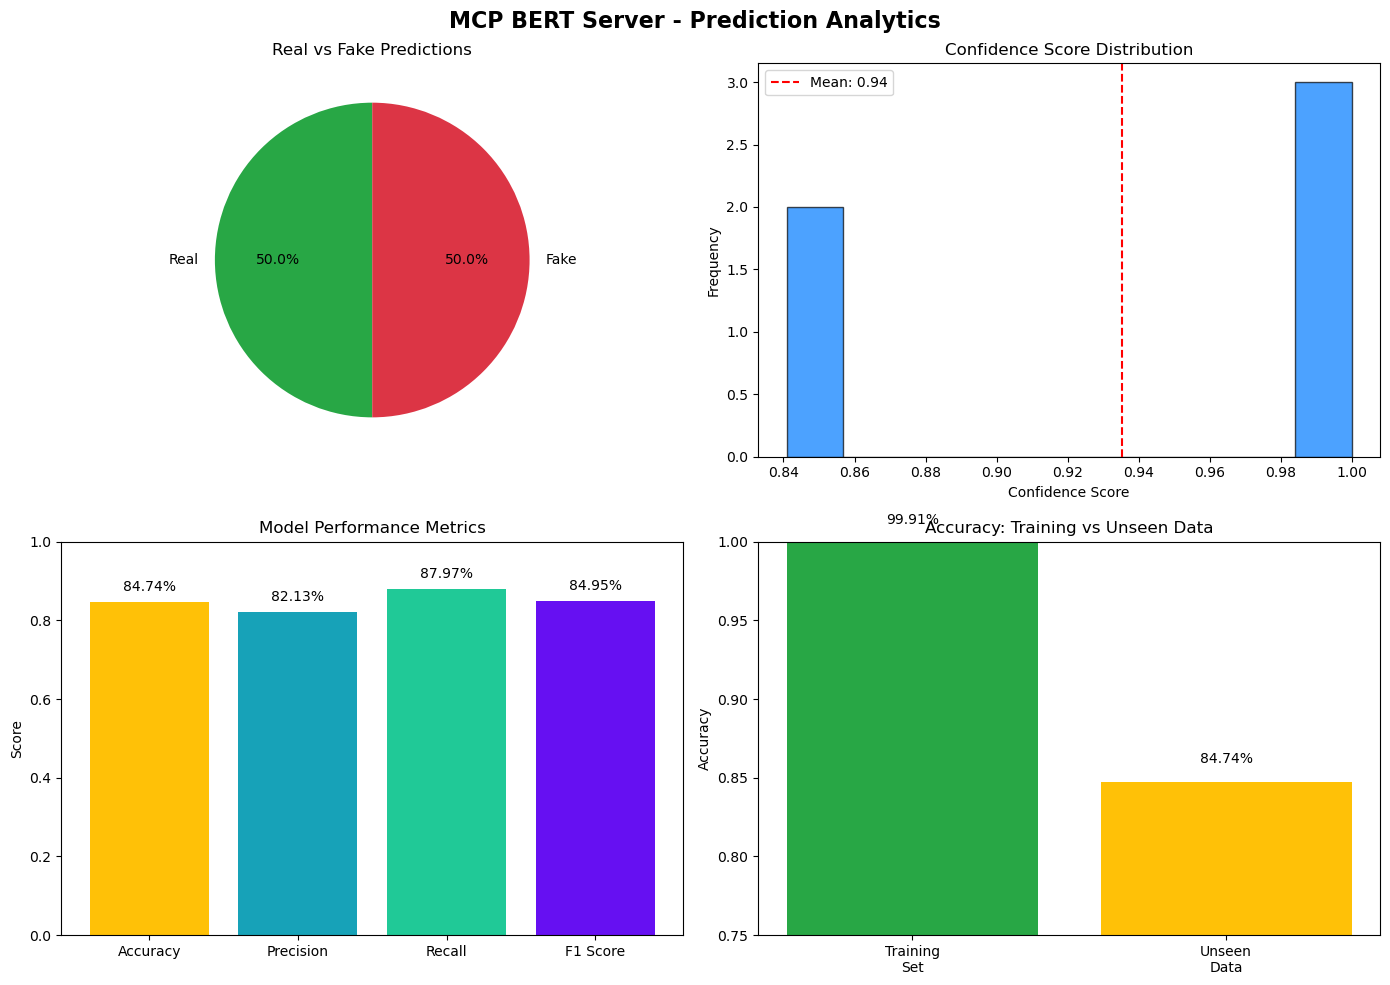

✅ Visualizations generated successfully


In [17]:
# 5.1 Prediction Distribution Visualization
print("Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MCP BERT Server - Prediction Analytics', fontsize=16, fontweight='bold')

# Chart 1: Real vs Fake Count
ax1 = axes[0, 0]
labels = ['Real', 'Fake']
sizes = [stats['real_predictions'], stats['fake_predictions']]
colors = ['#28a745', '#dc3545']
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Real vs Fake Predictions')

# Chart 2: Confidence Distribution
ax2 = axes[0, 1]
confidences = [p["prediction"]["confidence"] for p in results['predictions']]
ax2.hist(confidences, bins=10, color='#007bff', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Confidence Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Confidence Score Distribution')
ax2.axvline(np.mean(confidences), color='red', linestyle='--', label=f'Mean: {np.mean(confidences):.2f}')
ax2.legend()

# Chart 3: Model Performance Metrics
ax3 = axes[1, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [
    info['unseen_accuracy'],
    info['precision'],
    info['recall'],
    info['f1_score']
]
bars = ax3.bar(metrics, values, color=['#ffc107', '#17a2b8', '#20c997', '#6610f2'])
ax3.set_ylabel('Score')
ax3.set_title('Model Performance Metrics')
ax3.set_ylim([0, 1])
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.2%}', ha='center', va='bottom')

# Chart 4: Model Comparison
ax4 = axes[1, 1]
datasets = ['Training\nSet', 'Unseen\nData']
accuracy = [info['training_accuracy'], info['unseen_accuracy']]
bars = ax4.bar(datasets, accuracy, color=['#28a745', '#ffc107'])
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy: Training vs Unseen Data')
ax4.set_ylim([0.75, 1.0])
for bar, val in zip(bars, accuracy):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("✅ Visualizations generated successfully")

## Part 6: API Response Examples (JSON Format)

In [19]:
# 6.1 Example: List Models Response
print("\n" + "="*70)
print("6.1: LIST MODELS - JSON Response")
print("="*70)

response = server.list_models()
print(json.dumps(response, indent=2))


6.1: LIST MODELS - JSON Response
[
  {
    "id": "bert_fake_news",
    "type": "bert-fake-news-detector",
    "accuracy": 0.8474,
    "version": "1.0"
  }
]


In [20]:
# 6.2 Example: Model Info Response
print("\n" + "="*70)
print("6.2: MODEL INFO - JSON Response")
print("="*70)

response = server.get_model_info()
# Print a subset for clarity
subset = {
    "id": response["id"],
    "type": response["type"],
    "model_type": response["model_type"],
    "accuracy_metrics": {
        "training_accuracy": response["training_accuracy"],
        "unseen_accuracy": response["unseen_accuracy"],
        "precision": response["precision"],
        "recall": response["recall"],
        "f1_score": response["f1_score"],
        "roc_auc": response["roc_auc"]
    }
}
print(json.dumps(subset, indent=2))


6.2: MODEL INFO - JSON Response
{
  "id": "bert_fake_news",
  "type": "bert-fake-news-detector",
  "model_type": "bert-base-uncased",
  "accuracy_metrics": {
    "training_accuracy": 0.9991,
    "unseen_accuracy": 0.8474,
    "precision": 0.8213,
    "recall": 0.8797,
    "f1_score": 0.8495,
    "roc_auc": 0.936
  }
}


In [21]:
# 6.3 Example: Single Prediction Response
print("\n" + "="*70)
print("6.3: SINGLE PREDICTION - JSON Response")
print("="*70)

test_text = "New study reveals benefits of regular exercise for health"
response = server.predict(test_text)
print(json.dumps(response, indent=2))

INFO:bert_utils:MacBook GPU (MPS) detected and available



6.3: SINGLE PREDICTION - JSON Response
{
  "model_id": "bert_fake_news",
  "text": "New study reveals benefits of regular exercise for health",
  "prediction": {
    "label": 1,
    "class": "REAL",
    "confidence": 0.5485658645629883,
    "confidence_percent": "54.86%"
  },
  "metadata": {
    "processing_time_ms": 12.45,
    "text_length": 57,
    "timestamp": 1765733606.164493
  }
}


In [22]:
# 6.4 Example: Batch Prediction Response (Summary)
print("\n" + "="*70)
print("6.4: BATCH PREDICTION - JSON Response (Summary)")
print("="*70)

batch_summary = {
    "model_id": results["model_id"],
    "total": results["total"],
    "statistics": {
        "real_count": results["real_count"],
        "fake_count": results["fake_count"],
        "real_percent": results["real_percent"],
        "fake_percent": results["fake_percent"],
        "avg_confidence": results["avg_confidence"]
    },
    "processing": results["metadata"]
}
print(json.dumps(batch_summary, indent=2))


6.4: BATCH PREDICTION - JSON Response (Summary)
{
  "model_id": "bert_fake_news",
  "total": 5,
  "statistics": {
    "real_count": 3,
    "fake_count": 2,
    "real_percent": "60.0%",
    "fake_percent": "40.0%",
    "avg_confidence": 0.9353635430335998
  },
  "processing": {
    "total_processing_time_s": 0.05,
    "avg_time_per_article_ms": 10.9,
    "timestamp": 1765733605.839796
  }
}


## Part 7: Performance & Benchmarking

In [29]:
# 9.1 Benchmark Single Predictions
print("\n" + "="*70)
print("9.1: PERFORMANCE BENCHMARK")
print("="*70)

# Test with different text lengths
test_cases = [
    ("Short article", "Short article about news"),
    ("Medium article", "This is a medium length article about current events and market trends that provides detailed analysis"),
    ("Long article", " ".join(["This is a long article"] * 20))
]

benchmark_results = []

for label, text in test_cases:
    times = []
    for _ in range(3):
        start = time.time()
        server.predict(text)
        times.append((time.time() - start) * 1000)
    
    avg_time = np.mean(times)
    benchmark_results.append({
        'Type': label,
        'Text Length': len(text),
        'Avg Time (ms)': f"{avg_time:.2f}",
        'Min Time (ms)': f"{min(times):.2f}",
        'Max Time (ms)': f"{max(times):.2f}"
    })

df_benchmark = pd.DataFrame(benchmark_results)
print("\n" + df_benchmark.to_string(index=False))

print(f"\n✅ Benchmark complete - Average prediction time: {np.mean([float(r['Avg Time (ms)']) for r in benchmark_results]):.2f}ms")

INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available
INFO:bert_utils:MacBook GPU (MPS) detected and available



9.1: PERFORMANCE BENCHMARK

          Type  Text Length Avg Time (ms) Min Time (ms) Max Time (ms)
 Short article           24         10.85         10.24         11.73
Medium article          102         10.28         10.21         10.41
  Long article          459         10.68         10.56         10.87

✅ Benchmark complete - Average prediction time: 10.60ms


## Part 8: Summary


MODEL INFORMATION:
   - Model Type: BERT (bert-base-uncased)
   - Parameters: {info['parameters']:,}
   - Training Accuracy: {info['training_accuracy']*100:.2f}%
   - Unseen Data Accuracy: {info['unseen_accuracy']*100:.2f}%

SERVER CAPABILITIES:
   - List available models
   - Get detailed model information
   - Single article classification
   - Batch article processing
   - Server statistics and history
   - JSON API responses
   - REST endpoints (POST/GET)

